
<h3 align="center">SA4110 MACHINE LEARNING APPLICATION DEVELOPMENT</h3>
<h4 align="center">CA - GROUP 3 - IMAGE CLASSIFIER</h4>
<hr>

<div class="alert alert-block alert-info">
<b><u>Tasks:</u></b> 
<ol>
<li>Create an Image Classifier (CNN model) to classify images of fruits correctly.</li>
<li>A Fruits Dataset is provided that consists of these 3 Classes: -</li>
    <ul>
    <li>Apple</li>
    <li>Banana</li>
    <li>Orange</li>
    </ul>
<li>Use the Images in train.zip and test.zip to Train and Test your Image Classifier.</li>
<li>Document your experiments and results in improving your model’s accuracy.</li>
<li>The Following Activities can Improve your Model’s Accuracy: -</li>
    <ul>
    <li>Balance out the Number of Samples in Each Class</li>
    <li>Correct any mis-labelling in any of the 3 Classes</li>
    <li>Image Augmentation to Generate more Data </li>
    </ul>
<li>Use Matplotlib to Generate any Plots that can Help the Reader understand your Work Better.</li>
</ol></div>



## Set Up
1. Installations
2. Imports

In [1]:
# ========================================================== #
# 1. Verification of Base Libraries / Packages 
# ========================================================== #

import sys
import subprocess
import importlib.util

def verify_and_install():
    required_packages = {
        'pandas': 'pandas',
        'numpy': 'numpy',
        'matplotlib': 'matplotlib',
        'seaborn': 'seaborn',
        'IPython': 'ipython',
        'PIL': 'Pillow',
        'torch': 'torch',
        'torchvision': 'torchvision',
        'keras': 'keras',
        'sklearn': 'scikit-learn'
    }

    print("--- Verifying Environment Setup ---")
    
    for import_name, pip_name in required_packages.items():
        # Check if the module can be found in the host environment
        if importlib.util.find_spec(import_name) is None:
            print(f"❌ '{import_name}' is missing. Installing '{pip_name}'...")
            try:
                # Run pip install securely via the current python executable
                subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
                print(f"✅ Successfully installed '{pip_name}'.")
            except subprocess.CalledProcessError as e:
                # Stop the script if a critical package fails to install
                print(f"⚠️ Failed to install '{pip_name}'. Error: {e}")
                sys.exit(1) 
        else:
            print(f"✅ '{import_name}' is already installed.")
            
    print("-" * 70)
    print("All necessary packages are ready. Proceeding with the script...")
    print("-" * 70 + "\n")

# Run the verification before importing the third-party libraries
verify_and_install()

--- Verifying Environment Setup ---
✅ 'pandas' is already installed.
✅ 'numpy' is already installed.
✅ 'matplotlib' is already installed.
✅ 'seaborn' is already installed.
✅ 'IPython' is already installed.
✅ 'PIL' is already installed.
✅ 'torch' is already installed.
✅ 'torchvision' is already installed.
✅ 'keras' is already installed.
✅ 'sklearn' is already installed.
----------------------------------------------------------------------
All necessary packages are ready. Proceeding with the script...
----------------------------------------------------------------------



In [2]:
# ========================================================== #
# 2. Importing the Required Libraries and Packages
# ========================================================== #

# A. System and OS-level operations
import os
import gc
import statistics
from pathlib import Path
os.environ["KERAS_BACKEND"] = "torch"

# B. Data Manipulation and Mathematical Operations
import pandas as pd
import numpy as np

# C. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from IPython.display import Image as IPImage

# D. Image Processing
from PIL import Image

# E. Deep Learning Frameworks (PyTorch & Keras)
import keras
from keras import layers
from keras import backend as K
from keras.models import Sequential
from keras.layers import (
    Input, Conv2D, MaxPooling2D, 
    Flatten, Dense, Dropout, 
    GlobalAveragePooling2D, Rescaling
)
from keras.optimizers import Adam

import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# F. Machine Learning Utilities and Metrics (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# G. Time reporting
import time

# Clear session and random seeds
import random

K.clear_session()

def set_seeds(seed=42):
    # 1. Python
    random.seed(seed)
    
    # 2. NumPy operations
    np.random.seed(seed)
    
    # 3. Core PyTorch CPU operations
    torch.manual_seed(seed)
    
    # Keras setting
    keras.utils.set_random_seed(seed)
    
    print(f"✅ All random seeds locked globally to: {seed}")

# Set seed on generator for data loader
BATCH_SIZE=16
def make_dataloader(dataset, batch_size=BATCH_SIZE, shuffle=False, seed=42):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator if shuffle else None,
    )

# Execute the function
set_seeds()

✅ All random seeds locked globally to: 42


## Image Preprocessing
1. Load image from Test and Train folders
2. Remove mislabelled multi-fruit images from training dataset
3. Preprocess and label images
4. Data preparation

In [3]:
# ========================================================== #
# Helper: functions to render HTML components for display
# ========================================================== #
# Render dataframe as HTML table
def render_df(df, sample_size):

    # Dynamic sampling based on input size
    display_df = (
        df if sample_size == 0
        else df.sample(n=min(sample_size, len(df)))
    )
    
    return (display_df.style
        .set_properties(**{'text-align': 'center', 'color': 'black'})
        .set_table_styles([
            {'selector':'tr:nth-child(even)', 'props': [('background-color', 'azure')]},
            {'selector':'th', 'props':[('text-align', 'center'), ('color', 'black'), ('font-weight', 'bold')]},
            {'selector':'tr:nth-child(odd)', 'props':[('text-align', 'center'), ('background-color', 'paleturquoise')]}
        ])).to_html()

# Render section header as HTML line
def render_section_header(title):
    return f"<h4 style='text-align: left; margin-top: 15px; margin-bottom: 5px;'>{title}</h4>"

# Label value table
def render_key_value_table(rows):
    """
    rows = [
        ("Label 1", "Value 1"),
        ("Label 2", "Value 2"),
    ]
    """

    html = "<table style='margin: 0; text-align: left; border: none;'>"

    for i, (label, value) in enumerate(rows):
        bg = "paleturquoise" if i % 2 == 0 else "azure"

        html += f"""
        <tr style='background-color: {bg};'>
            <td style='color: black; text-align: center; padding-right: 10px; border: none;'>
                <strong>{label}</strong>
            </td>
            <td style='color: black; text-align: center; border: none;'>{value} </td>
        </tr>
        """

    html += "</table>"
    return html

# Status messages
def render_status_list(messages):
    """
    messages = [
        ("green", "Success"),
        ("red", "Failure")
    ]
    """

    html = "<ul style='text-align: left;'>"

    for color, msg in messages:
        html += f"<li style='color: {color};'>{msg}</li>"

    html += "</ul>"
    return html

# Line separator
def render_separator():
    return "<hr style='margin-top: 15px; border-top: 1px solid #ddd;'>"

# Not found message
def render_no_images_message():
    return "<div style='color: red; text-align: center;'>No valid .jpg images found.</div>"

# Display dataset inspect
def render_dataset_info(train_logs, train_html, test_logs, test_html):
    return f"""
    <div style="display: flex; flex-direction: row; justify-content: space-around; align-items: flex-start; gap: 20px;">
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Training & Validation Dataset</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {train_logs}
            </div>
            <h4 style="text-align: left;">DataFrame Sample</h4>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {train_html}
            </div>
        </div>
        
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Testing Dataset</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {test_logs}
            </div>
            <h4 style="text-align: left;">DataFrame Sample</h4>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {test_html}
            </div>
        </div>
    </div>
    """

# Display data set info
def render_dataset_shapes(train_shape_html, val_shape_html, class_test_shape_html):
    return f"""
    <div style="display: flex; flex-direction: row; justify-content: space-around; align-items: flex-start; gap: 20px;">
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Training (80%)<br>Dataset Shape</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {train_shape_html}
            </div>
        </div>
        
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Validation (20%)<br>Dataset Shape</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {val_shape_html}
            </div>
        </div>
    
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Testing<br>Dataset Shape</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {class_test_shape_html}
            </div>
        </div>
    </div>
    """

In [4]:
# ========================================================== #
# Helper: Load and Process the Image Data from the Directories
# Purpose: Scan the 'train' and 'test' directories for .jpg 
# images, extract class labels from filenames, calculate 
# median dimensions, and compile the data into DataFrames 
# for prior for model training and evaluation.
# ========================================================== #
EXCLUDED_IMAGES = [
    'banana_35.jpg',
    'banana_61.jpg'
]

def process_image_directory(directory_path, dataset_name="Dataset"):
    
    file_names = []
    class_labels = []
    widths = []
    heights = []
    status_messages = []
    
    excluded_count = 0

    # Single pass through the directory
    for img_path in sorted(directory_path.glob("*.jpg")):
        
        # Skip excluded images
        if EXCLUDED_IMAGES is not None and img_path.name in EXCLUDED_IMAGES:
            excluded_count += 1
            continue
        
        try:
            # A. Open a valid data image file and extract its dimensions
            with Image.open(img_path) as img:
                widths.append(img.size[0])
                heights.append(img.size[1])
                
            # B. Extract metadata ONLY if the image opened successfully
            file_names.append(img_path.name)
            class_labels.append(img_path.name.strip().split('_')[0])
            
        except Exception as e:
            # C. Exception handling for invalid data image file
            status_messages.append(("red", f"Error reading {img_path.name}: {e}"))

    # Success message if no errors
    if not status_messages:
        status_messages.append(("green", "All images read successfully without errors."))

    # Build the DataFrame Table of Consisting of File Name and its Classes
    df = pd.DataFrame({
        'fileName': file_names,
        'classLabel': class_labels
    })

    # Build HTML Report

    log_html = ""

    log_html += render_section_header("Processing Status")
    log_html += render_status_list(status_messages)

    log_html += render_section_header("Class Labels Found")
    log_html += render_key_value_table([
        (f"Class {i}", label)
        for i, label in enumerate(df['classLabel'].unique(), start = 1)
    ])

    # Calculate Medians of the data images 
    median_w, median_h = 0, 0
    log_html += render_section_header("<br>Dataset Statistics")
    
    if widths and heights:
        median_w = statistics.median(widths)
        median_h = statistics.median(heights)
        
        log_html += render_key_value_table([
            ("Total Images Evaluated", len(widths)),
            ("Images Excluded", excluded_count),
            ("Image Median Width", f"{median_w} px"),
            ("Image Median Height", f"{median_h} px")
        ])
    else:
        log_html += render_no_images_message()
        
    log_html += render_separator()
        
    return df, median_w, median_h, log_html

Excluded Image due to mislabelling caused by multiple fruits in one
banana_35.jpg


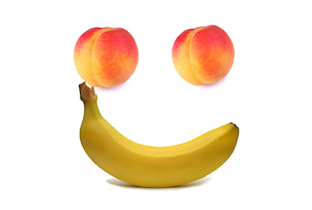

banana_61.jpg


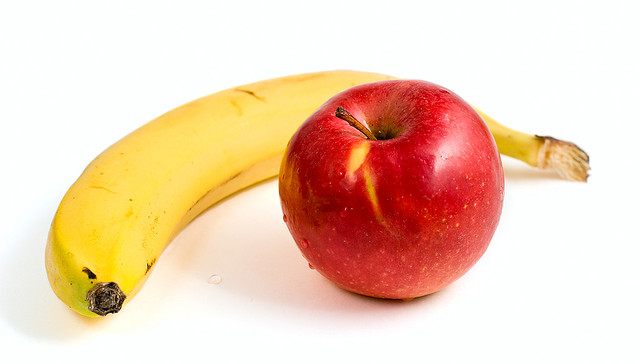

In [5]:
# ---------------------------------------------------------- #
# Execute the Function for Both Directories
# ---------------------------------------------------------- #
# Define the path directories
base_dir = Path.cwd()
img_train_dir = base_dir / "train"
img_test_dir = base_dir / "test"

# Process Training and Validation Datasets from 'train' directory
class_train_df, img_T_widths_median, img_T_heights_median, train_logs = process_image_directory(
    directory_path = img_train_dir, 
    dataset_name = "Training and Validation Dataset"
)

# Sampling of the training and validation dataframe for verification
train_html = render_df(class_train_df, 5)

# Process Testing Datasets from 'test' directory
class_test_df, img_t_widths_median, img_t_heights_median, test_logs = process_image_directory(
    directory_path = img_test_dir, 
    dataset_name = "Testing Dataset"
)

# Sampling of the testing dataframe for verification
test_html = render_df(class_test_df, 5)

# Wrapping them html in a Flex container to enable side-by-side display
train_test_html = render_dataset_info(train_logs, train_html, test_logs, test_html)
display(HTML(train_test_html))

# Display excluded images
print(f"Excluded Image due to mislabelling caused by multiple fruits in one")
for img_name in EXCLUDED_IMAGES:
    img_path = img_train_dir / img_name
    print(f"{img_name}")
    display(IPImage(filename=img_path, width=200))


In [6]:
# ========================================================== #
# Helper: Define FruitLabeller class and supporting functions
# Purpose: Create a custom PyTorch Dataset to load images, apply 
# transformations, and encode string labels to numeric indices 
# using a provided DataFrame.
# ========================================================== #
label_map = {
    label: idx
    for idx, label in enumerate(sorted(class_train_df["classLabel"].unique()))
}

class FruitLabeller(Dataset):
    def __init__(self, class_dataframe, img_directory, transforms = None, label_map=None):
        self.dataframe = class_dataframe
        self.directory = img_directory
        self.transforms = transforms
        
        if label_map is None:
            unique_labels = sorted(class_dataframe["classLabel"].unique())
            self.label_map = {label: idx for idx, label in enumerate(unique_labels)}
        else:
            self.label_map = label_map
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['fileName']
        img_path = self.directory / img_name
        image = Image.open(img_path).convert("RGB")

        label_str = self.dataframe.iloc[idx]['classLabel']
        label = self.label_map[label_str]

        if self.transforms:
            image = self.transforms(image)
        
        return image, label
    
def render_dataset_shape(df):
    shape_df = df['classLabel'].value_counts().sort_index().reset_index()
    shape_df.columns = ['Class Label', 'Total Image']
    return shape_df

In [7]:
# Helper: data preparation
def transform(mean=None, std=None, data_augmentation=None):
    transforms_list = [ transforms.Resize((224, 224)) ]

    if data_augmentation is not None:
        transforms_list.extend(data_augmentation)
        
    transforms_list.append(transforms.ToTensor())
    
    if mean is not None and std is not None:
        transforms_list.append(
            transforms.Normalize(
                mean = mean.tolist(),
                std = std.tolist()
            )
        )
        
    return transforms.Compose(transforms_list)

In [8]:
# ========================================================== #
# 3. Data preparation
# ========================================================== #

# Split Data (80% Train, 20% Val)
train_df, val_df = train_test_split(
    class_train_df,
    test_size=0.2,
    random_state=42,
    stratify=class_train_df['classLabel']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Temporary / display transforms
temp_transforms = transform()
temp_dataset = FruitLabeller(train_df, img_train_dir, temp_transforms, label_map)
temp_loader = make_dataloader(temp_dataset, batch_size=len(temp_dataset), shuffle=False)

# Normalise pixel values for better accuracy
temp_images, temp_labels = next(iter(temp_loader))
mean, std = temp_images.mean(dim=(0,2,3)), temp_images.std(dim=(0,2,3))
print(f"Mean: {mean}\nStd: {std}")

# Actual transforms
actual_transforms = transform(mean, std)

# Instantiate PyTorch Datasets
train_dataset = FruitLabeller(train_df, img_train_dir, actual_transforms, label_map)
val_dataset = FruitLabeller(val_df, img_train_dir, actual_transforms, label_map)
test_dataset = FruitLabeller(class_test_df, img_test_dir, actual_transforms, label_map)

# Create PyTorch DataLoaders
train_loader = make_dataloader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_dataloader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = make_dataloader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Display Dataset Shapes
train_shape_html = render_df(render_dataset_shape(train_df), 0)
val_shape_html = render_df(render_dataset_shape(val_df), 0)
class_test_shape_html = render_df(render_dataset_shape(class_test_df), 0)

# Because sample classes are already balanced, no resampling was performed
dataset_shapes_html = render_dataset_shapes(train_shape_html, val_shape_html, class_test_shape_html)
display(HTML(dataset_shapes_html))

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Mean: tensor([0.8105, 0.6848, 0.5310])
Std: tensor([0.2753, 0.3213, 0.4042])


,Class Label,Total Image
0,apple,60
1,banana,57
2,orange,57
,Class Label,Total Image
0,apple,15
1,banana,14
2,orange,15
,Class Label,Total Image
0,apple,19
1,banana,18


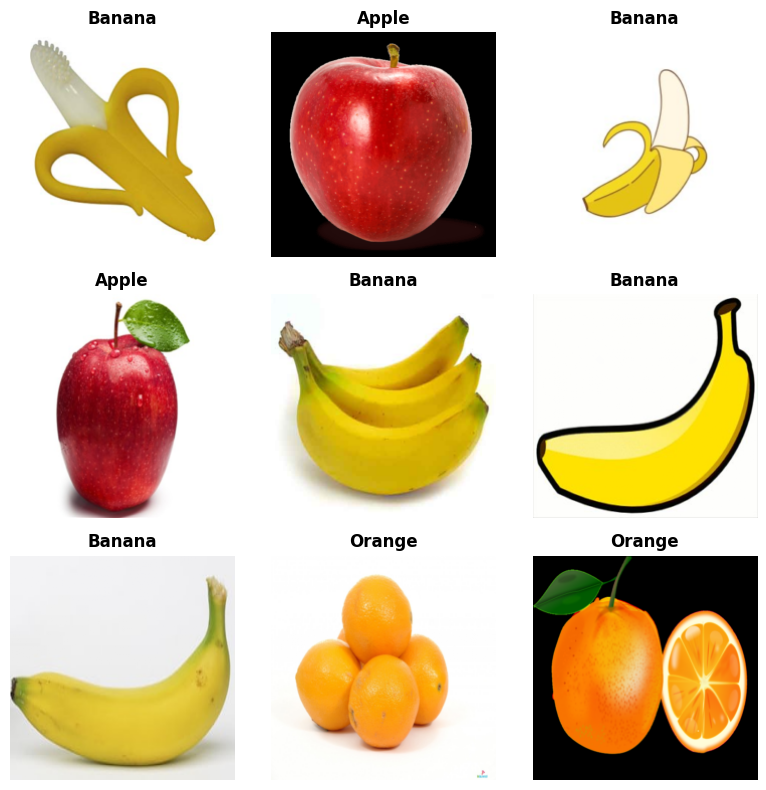

In [9]:
# Display Sample Images (Unnormalised)
class_names = {v: k for k, v in label_map.items()}

# Set up a MatPlotLib Grid
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = np.transpose(temp_images[i].numpy(), (1, 2, 0))
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    
    # Look up the Integer Label in the Dictionary and Set it as the Title
    label_idx = temp_labels[i].item()
    ax.set_title(class_names[label_idx].capitalize(), fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Helper functions for experimentation with models
1. Building model
2. Compiling model
3. Training model
4. Evaluating model and rendering results

In [10]:
# ========================================================== #
# Helper: Build and Compile CNN Architecture (224 x 224 x 3)
# By default no dropout or augmentation
# ========================================================== #
def build_model(dropout_rate = 0.0):
    model_layers = [
        Input(shape=(3, 224, 224)),

        # Conv1: 32 filters, Output shape: 224 x 224 x 32
        Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            data_format="channels_first" # PyTorch default
        ),
    
        # MaxPool: 224 x 224 -> 112 x 112
        MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),
    
        # Conv2: 64 filters, output shape: 112 x 112 x 64
        Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            data_format="channels_first"
        ),
    
        # MaxPool: 112 x 112 -> 56 x 56
        MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),
        
        
        # Conv3: 128 filters, output shape: 56 x 56 x 128
        Conv2D(
            filters=128,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            data_format="channels_first"
        ),
    
        # MaxPool: 56 x 56 -> 28 x 28
        MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),
        
        # Flatten: 28 x 28 x 128 = 100,352
        Flatten(),
    
        # Fully connected layer
        Dense(128, activation="relu"),
        
        # Dropout layer
        Dropout(dropout_rate),

        # Output Layer: 3 nodes (Apples, Bananas, Oranges)
        Dense(3, activation='softmax')
    ]
    
    return Sequential(model_layers)

In [11]:
# ========================================================== #
# Helper: Compile model
# ========================================================== #
def compile_model(model, learning_rate = 0.001):
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

In [12]:
# ========================================================== #
# Helper: Train CNN Model
# Epochs at 20 to allow liberal and fair experimentation
# ========================================================== #
def train_model(model, epoch=20, loader=train_loader):
    start = time.perf_counter()
    
    class GarbageCollectorCallback(keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            gc.collect()

    history = model.fit(
        loader,
        validation_data=val_loader,
        epochs=epoch,
        verbose=0,
        callbacks = [ GarbageCollectorCallback() ]
    )

    end = time.perf_counter()
    training_time = end - start
    return history, training_time


In [13]:
# ==========================================================
# Helper: Evaluate model and render results
# ==========================================================

MODEL_KEY_ALIASES = {
    'Baseline Model': 'baseline',
    'Learning Rate 0.01 Model': 'lr_01',
    'Learning Rate 0.0001 Model': 'lr_0001',
    'Dropout 0.7 Model': 'dropout_07',
    'Dropout 0.5 Model': 'dropout_05',
    'Dropout 0.3 Model': 'dropout_03',
    'Geometric Aug Model': 'augmentation_exp3a',
    'Geometric + Blur Aug Model': 'augmentation_exp3b',
    'Photometric Aug Model': 'augmentation_exp3c',
    'Geometric + Photometric Aug Model': 'augmentation_exp3d',
    'MobileNetV2 TL Model': 'transferlearning_exp4',
    'Fine-Tuned MobileNetV2 TL Model': 'transferlearning_finetuned'
}

# Get predictions for model
# Track processing time for experiment comparison
def get_predictions(model):

    start = time.perf_counter()
    
    # Initialize lists to store true and predicted labels for the entire dataset
    y_true, y_pred = [], []
    
    # Iterate through the entire test_loader
    for test_images, test_labels in test_loader:
        # Get predictions for the current batch (verbose=0 suppresses per-batch output)
        batch_preds_prob = model.predict(test_images, verbose=0)
        batch_preds = np.argmax(batch_preds_prob, axis=1)
        
        # Append the results to the tracking lists
        y_true.extend(test_labels.numpy())
        y_pred.extend(batch_preds)

    end = time.perf_counter()
    inference_time = end - start

    return y_true, y_pred, inference_time

# Set target names
target_names = [
    name for name in label_map.keys()
]

# Evaluation result builder
def build_result(
    model_name,
    history,
    y_true,
    y_pred,
    training_time,
    inference_time,
    test_accuracy,
    test_loss
):
    report = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )

    return {
        'name': model_name,
        'key': MODEL_KEY_ALIASES[model_name],
        'history': history,

        # For experiment comparison
        'test_accuracy': report['accuracy'] if test_accuracy is None else test_accuracy,
        'test_loss': test_loss,

        # For individual reporting
        'classification_report': pd.DataFrame(report)
            .transpose()
            .round(3),
        'confusion_matrix': confusion_matrix(y_true, y_pred),

        # Processing times
        'training_time': training_time,
        'inference_time': inference_time
    }

# Generate and show accuracy and loss graphs using matplotlib
def render_accuracy_loss_report(result, epoch_max=21):
    # Extract Key Metrics from the history object
    history = result['history']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)
    
    sns.set_theme(style='darkgrid')
    plt.figure(figsize=(12, 5))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='blue')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='darkorange')
    plt.title(f'Training and Validation Accuracy', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=10, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=10, fontweight='bold')
    plt.legend(loc='lower right')
    plt.xlim(0, epoch_max)
    plt.ylim(0, 1.1)
    plt.grid(True)
    
    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='blue')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='darkorange')
    plt.title(f'Training and Validation Loss', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=10, fontweight='bold')
    plt.ylabel('Loss', fontsize=10, fontweight='bold')
    plt.legend(loc='upper right')
    plt.xlim(0, epoch_max)
    plt.grid(True)
    
    plt.tight_layout()
    
    print(f'\nAccuracy and Loss Report: {result["name"]}')
    plt.show()
    
    print(f'\nFinal Test Accuracy: {result["test_accuracy"]:.4f}')
    print(f'Final Test Loss: {result["test_loss"]:.4f}')

# Render classification report as HTML table
def render_classification_report(result):
    print(f'\nClassification Report: {result['name']}')
    report_html = render_df(result['classification_report'], 0)
    display(HTML(report_html))

# Render confusion matrix with matplotlib instead of HTML image embedding
def render_confusion_matrix(result):    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        result['confusion_matrix'],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names
    )
    plt.title(f'Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    print(f'\nConfusion Matrix: {result['name']}')
    plt.show()

## Baseline Model
### Learning Rate 0.001, Dropout 0.0
1. Build CNN architecture
2. Compile model
3. Train model
4. Evaluate model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Accuracy and Loss Report: Baseline Model


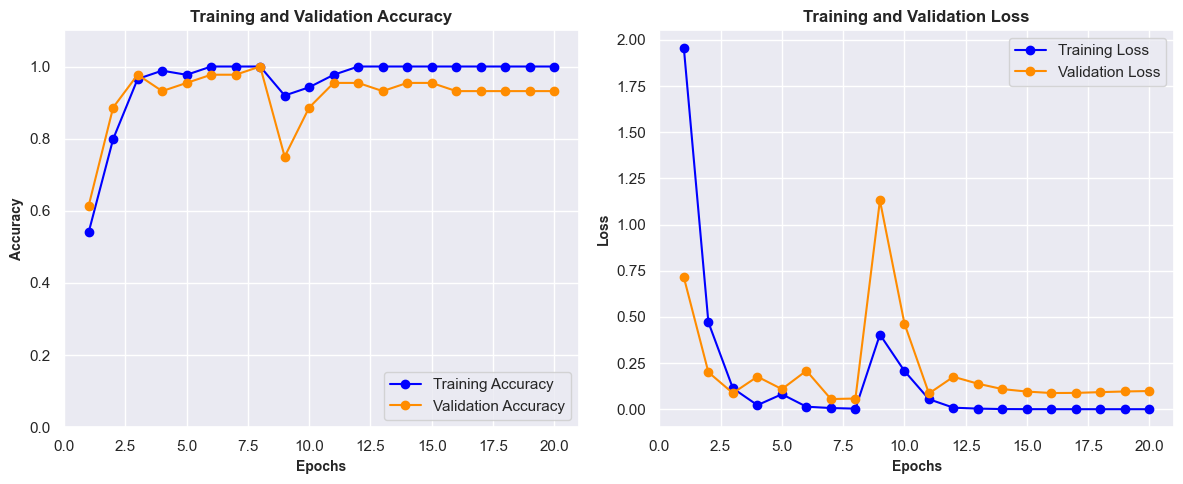


Final Test Accuracy: 0.9636
Final Test Loss: 0.2307

Classification Report: Baseline Model


,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.947000,1.000000,0.973000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.966000,0.963000,0.963000,55.000000
weighted avg,0.966000,0.964000,0.963000,55.000000



Confusion Matrix: Baseline Model


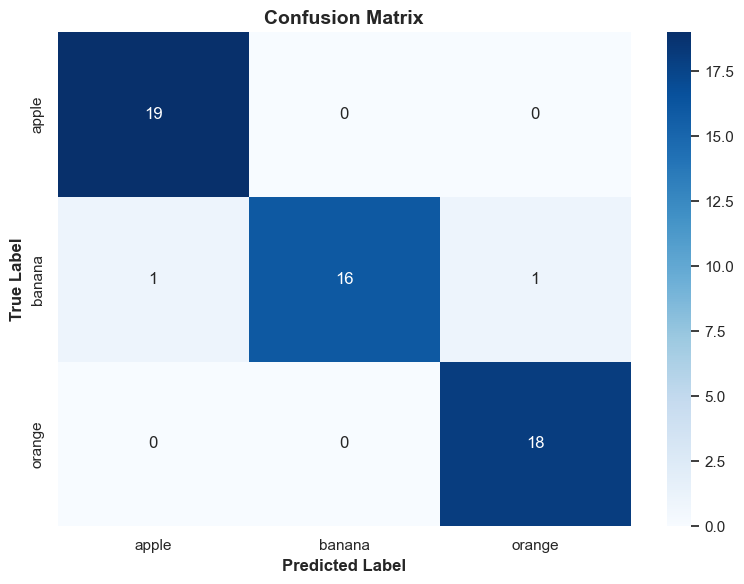

In [14]:
# ========================================================== #
# 4. Baseline Model: Learning Rate at 0.001, Epochs = 20
# ========================================================== #
# Compile and train model
baseline_model = build_model()
compile_model(baseline_model)
baseline_model.summary()
baseline_history, baseline_training_time = train_model(baseline_model)

# Get predictions for model
y_true, y_pred, baseline_inference_time = get_predictions(baseline_model)
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(test_loader, verbose=0)

# Build evaluation result
baseline_result = build_result(
    "Baseline Model",
    baseline_history,
    y_true,
    y_pred,
    baseline_training_time,
    baseline_inference_time,
    baseline_test_accuracy,
    baseline_test_loss
)

# Generate accuracy/loss, classification, confusion matrix reports
render_accuracy_loss_report(baseline_result)
render_classification_report(baseline_result)
render_confusion_matrix(baseline_result)

## Experiment 2: Improved Model with Hyperparameter Tuning

### Experiment 2A: Learning Rate 0.01

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Accuracy and Loss Report: Learning Rate 0.01 Model


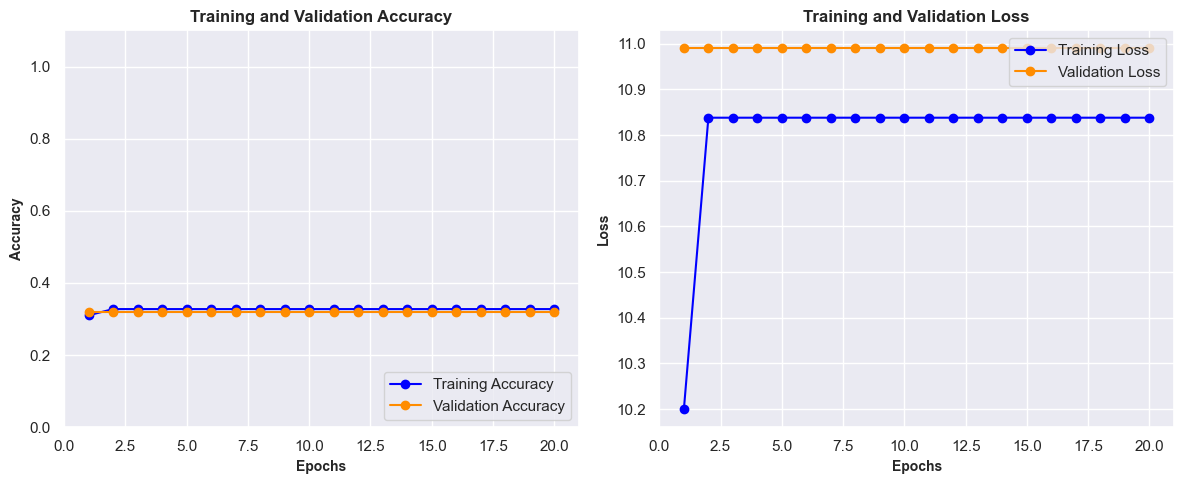


Final Test Accuracy: 0.3273
Final Test Loss: 10.8431

Classification Report: Learning Rate 0.01 Model


,precision,recall,f1-score,support
apple,0.000000,0.000000,0.000000,19.000000
banana,0.327000,1.000000,0.493000,18.000000
orange,0.000000,0.000000,0.000000,18.000000
accuracy,0.327000,0.327000,0.327000,0.327000
macro avg,0.109000,0.333000,0.164000,55.000000
weighted avg,0.107000,0.327000,0.161000,55.000000



Confusion Matrix: Learning Rate 0.01 Model


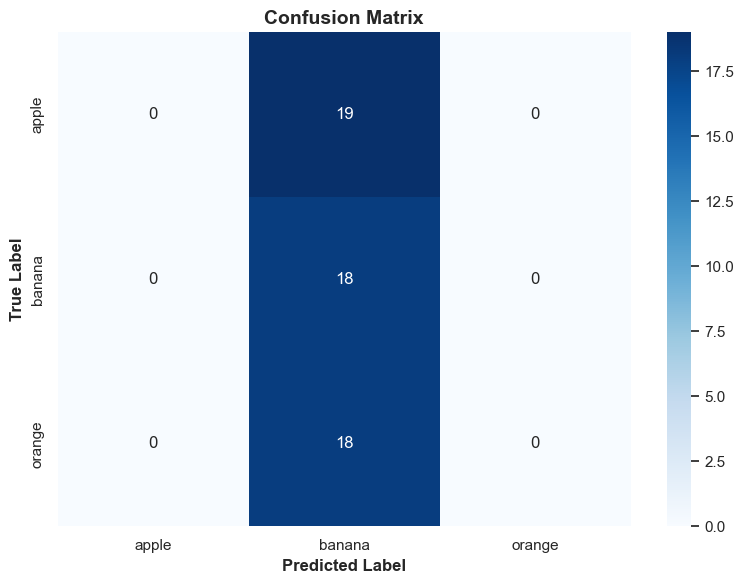

In [15]:
# ====================================================================== #
# 5. Improved Model with Learning Rate at 0.01, Epochs = 20
# ====================================================================== #
# Build and train model
LR_01_model = build_model()
compile_model(LR_01_model, 0.01)
LR_01_history, LR_01_training_time = train_model(LR_01_model)

# Get predictions for model
y_true, y_pred, LR_01_inference_time = get_predictions(LR_01_model)
LR_01_test_loss, LR_01_test_accuracy = LR_01_model.evaluate(test_loader, verbose=0)

# Build evaluation result
LR_01_result = build_result(
    "Learning Rate 0.01 Model",
    LR_01_history,
    y_true,
    y_pred,
    LR_01_training_time,
    LR_01_inference_time,
    LR_01_test_accuracy,
    LR_01_test_loss
)

# Generate accuracy/loss, classification, confusion matrix reports
render_accuracy_loss_report(LR_01_result)
render_classification_report(LR_01_result)
render_confusion_matrix(LR_01_result)

### Experiment 2B: Learning Rate 0.0001

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Accuracy and Loss Report: Learning Rate 0.0001 Model


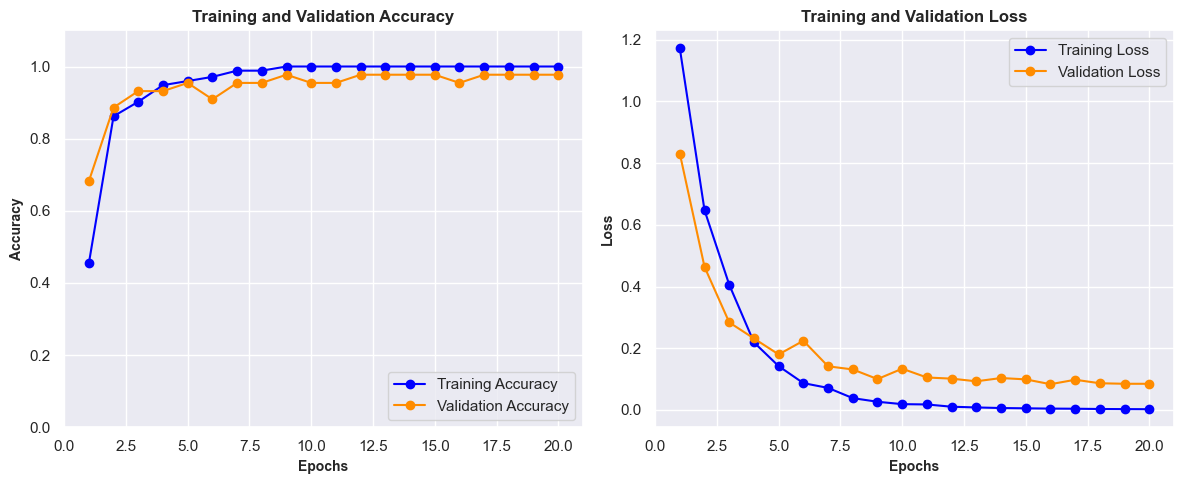


Final Test Accuracy: 0.9273
Final Test Loss: 0.3293

Classification Report: Learning Rate 0.0001 Model


,precision,recall,f1-score,support
apple,0.900000,0.947000,0.923000,19.000000
banana,0.941000,0.889000,0.914000,18.000000
orange,0.944000,0.944000,0.944000,18.000000
accuracy,0.927000,0.927000,0.927000,0.927000
macro avg,0.929000,0.927000,0.927000,55.000000
weighted avg,0.928000,0.927000,0.927000,55.000000



Confusion Matrix: Learning Rate 0.0001 Model


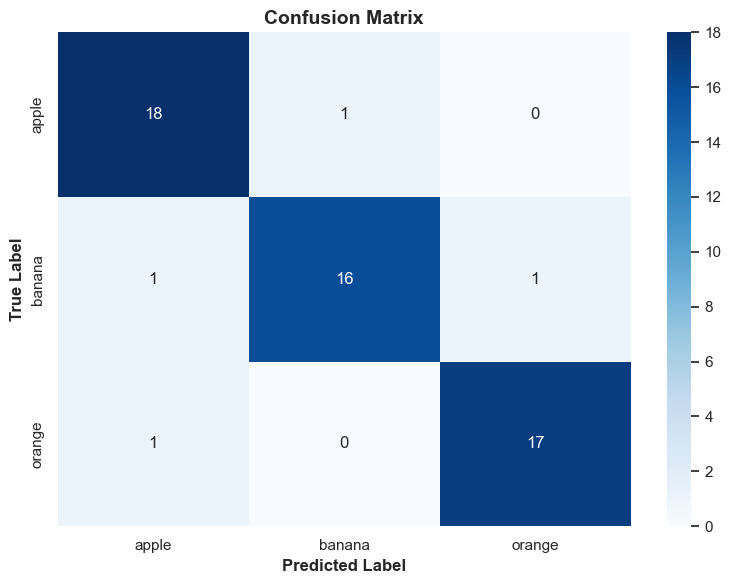

In [16]:
# ====================================================================== #
# 6. Improved Model with Learning Rate at 0.0001, Epochs = 20
# ====================================================================== #
# build and train model
LR_0001_model = build_model()
compile_model(LR_0001_model, 0.0001)
LR_0001_history, LR_0001_training_time = train_model(LR_0001_model)

# Get predictions for model
y_true, y_pred, LR_0001_inference_time = get_predictions(LR_0001_model)
LR_0001_test_loss, LR_0001_test_accuracy = LR_0001_model.evaluate(test_loader, verbose=0)

# Build evaluation result
LR_0001_result = build_result(
    "Learning Rate 0.0001 Model",
    LR_0001_history,
    y_true,
    y_pred,
    LR_0001_training_time,
    LR_0001_inference_time,
    LR_0001_test_accuracy,
    LR_0001_test_loss
)

# Generate accuracy/loss, classification, confusion matrix reports
render_accuracy_loss_report(LR_0001_result)
render_classification_report(LR_0001_result)
render_confusion_matrix(LR_0001_result)

### Experiment 2C: Best Learning Rate + Dropout 0.7

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Accuracy and Loss Report: Dropout 0.7 Model


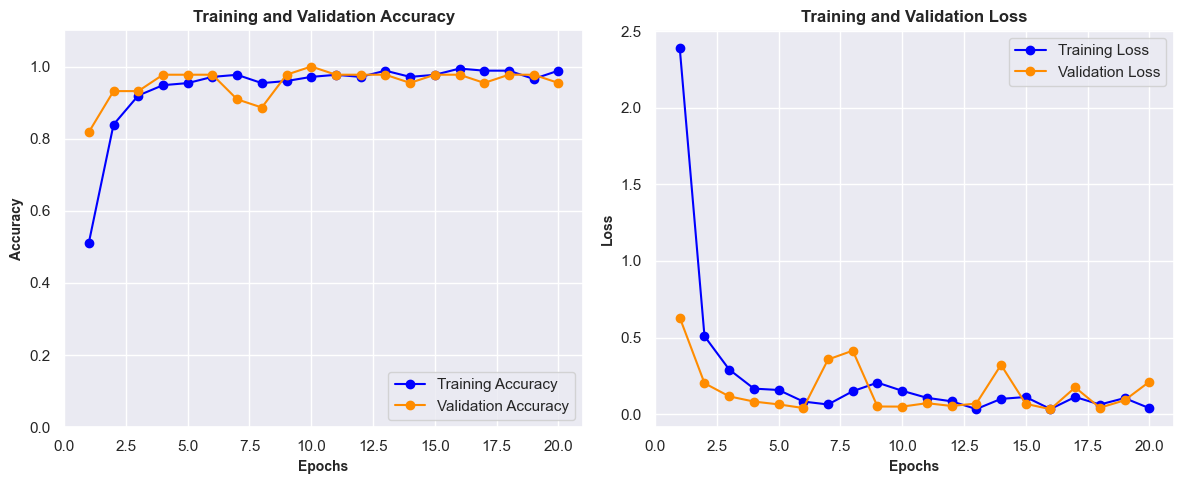


Final Test Accuracy: 0.9455
Final Test Loss: 0.4740

Classification Report: Dropout 0.7 Model


,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.833000,0.909000,18.000000
orange,0.900000,1.000000,0.947000,18.000000
accuracy,0.945000,0.945000,0.945000,0.945000
macro avg,0.950000,0.944000,0.944000,55.000000
weighted avg,0.950000,0.945000,0.944000,55.000000



Confusion Matrix: Dropout 0.7 Model


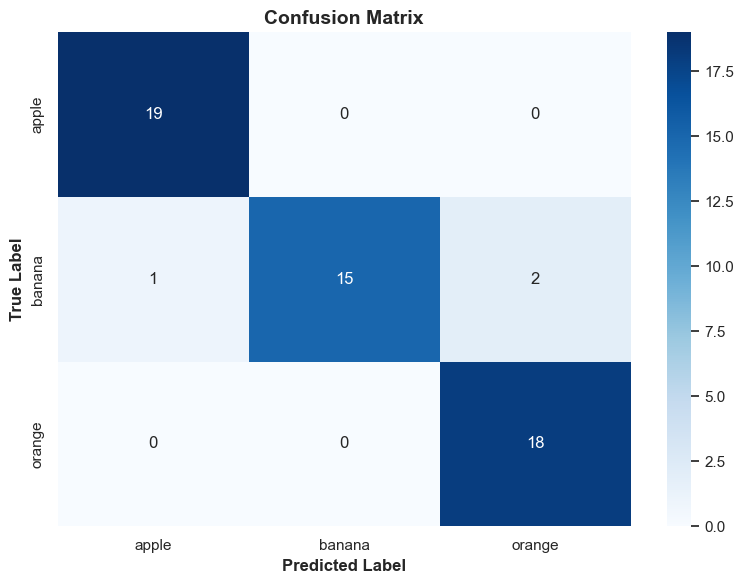

In [17]:
# ========================================================== #
# 7. Improved Model with Dropout at 0.7
# ========================================================== #
# Build and train model
dropout_07_model = build_model(0.7)
compile_model(dropout_07_model)
dropout_07_history, dropout_07_training_time = train_model(dropout_07_model)

# Get predictions for model
y_true, y_pred, dropout_07_inference_time = get_predictions(dropout_07_model)
dropout_07_test_loss, dropout_07_test_accuracy = dropout_07_model.evaluate(test_loader, verbose=0)

# Build evaluation result
dropout_07_result = build_result(
    "Dropout 0.7 Model",
    dropout_07_history,
    y_true,
    y_pred,
    dropout_07_training_time,
    dropout_07_inference_time,
    dropout_07_test_accuracy,
    dropout_07_test_loss
)

# Generate accuracy/loss, classification, confusion matrix reports
render_accuracy_loss_report(dropout_07_result)
render_classification_report(dropout_07_result)
render_confusion_matrix(dropout_07_result)

### Experiment 2D: Best Learning Rate + Dropout 0.5

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Accuracy and Loss Report: Dropout 0.5 Model


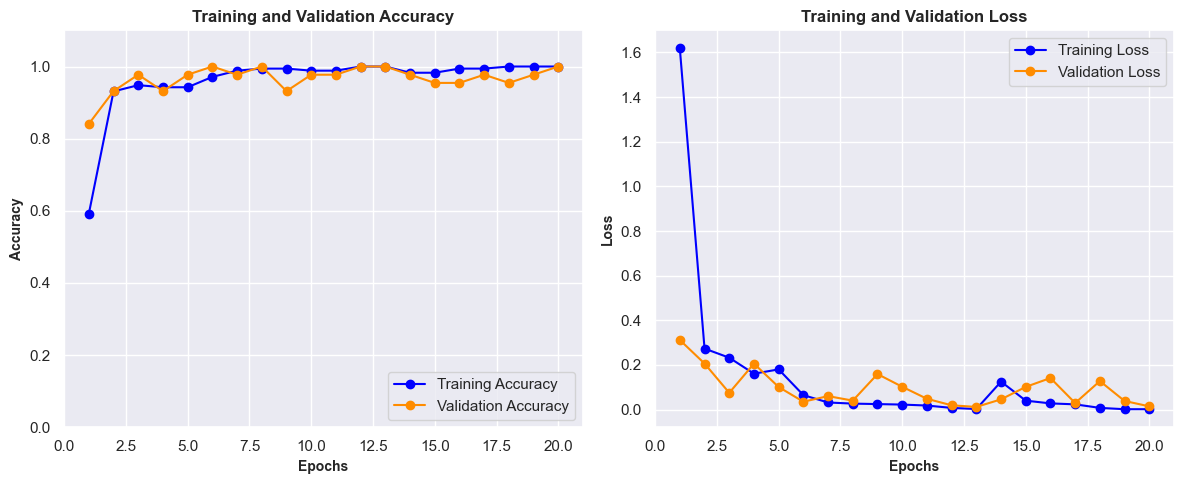


Final Test Accuracy: 0.9636
Final Test Loss: 0.3254

Classification Report: Dropout 0.5 Model


,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.947000,1.000000,0.973000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.966000,0.963000,0.963000,55.000000
weighted avg,0.966000,0.964000,0.963000,55.000000



Confusion Matrix: Dropout 0.5 Model


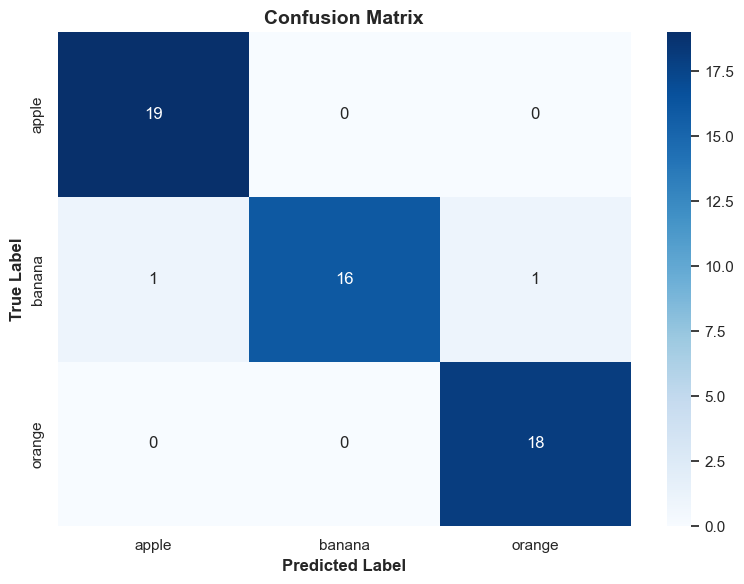

In [18]:
# ========================================================== #
# 8. Improved Model with Dropout at 0.5
# ========================================================== #
# Build and train model
dropout_05_model = build_model(0.5)
compile_model(dropout_05_model)
dropout_05_history, dropout_05_training_time = train_model(dropout_05_model)

# Get predictions for model
y_true, y_pred, dropout_05_inference_time = get_predictions(dropout_05_model)
dropout_05_test_loss, dropout_05_test_accuracy = dropout_05_model.evaluate(test_loader, verbose=0)

# Build evaluation result
dropout_05_result = build_result(
    "Dropout 0.5 Model",
    dropout_05_history,
    y_true,
    y_pred,
    dropout_05_training_time,
    dropout_05_inference_time,
    dropout_05_test_accuracy,
    dropout_05_test_loss
)

# Generate accuracy/loss, classification, confusion matrix reports
render_accuracy_loss_report(dropout_05_result)
render_classification_report(dropout_05_result)
render_confusion_matrix(dropout_05_result)

### Experiment 2E: Best Learning Rate + Dropout 0.3

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Accuracy and Loss Report: Dropout 0.3 Model


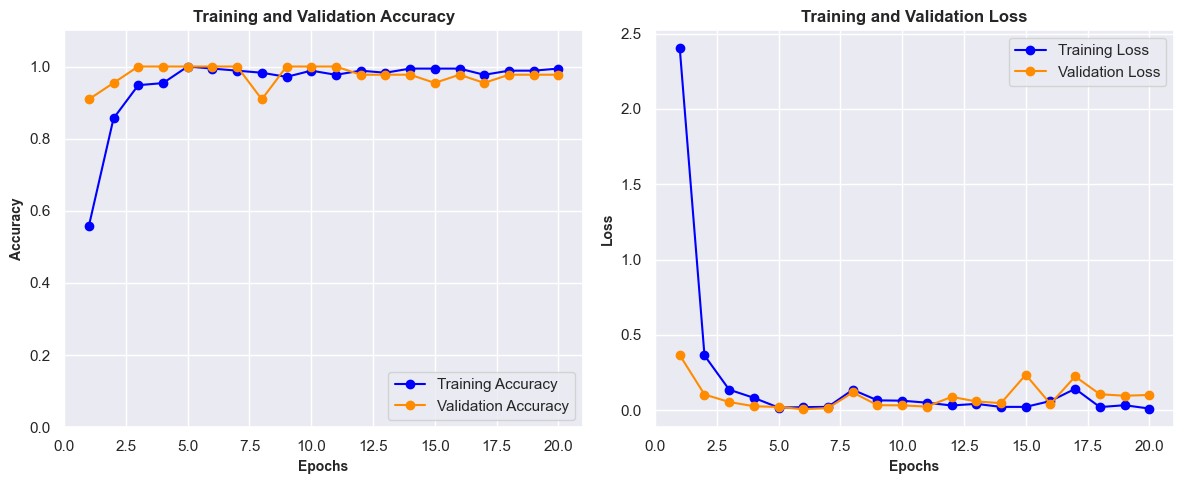


Final Test Accuracy: 0.9636
Final Test Loss: 0.3398

Classification Report: Dropout 0.3 Model


,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,0.944000,0.944000,0.944000,18.000000
orange,1.000000,0.944000,0.971000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.965000,0.963000,0.963000,55.000000
weighted avg,0.965000,0.964000,0.964000,55.000000



Confusion Matrix: Dropout 0.3 Model


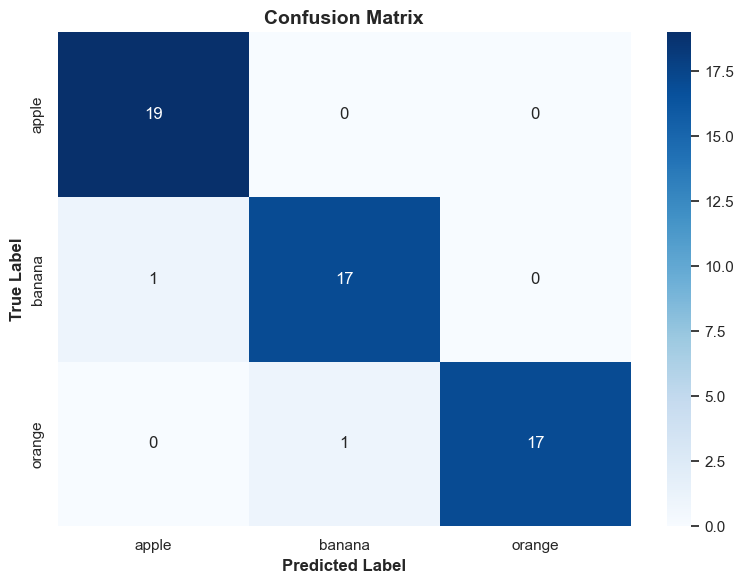

In [19]:
# ========================================================== #
# 9. Compile and Train Model with Dropout at 0.3
# ========================================================== #
# Build and train model
dropout_03_model = build_model(0.3)
compile_model(dropout_03_model)
dropout_03_history, dropout_03_training_time = train_model(dropout_03_model)

# Get predictions for model
y_true, y_pred, dropout_03_inference_time = get_predictions(dropout_03_model)
dropout_03_test_loss, dropout_03_test_accuracy = dropout_03_model.evaluate(test_loader, verbose=0)

# Build evaluation result
dropout_03_result = build_result(
    "Dropout 0.3 Model",
    dropout_03_history,
    y_true,
    y_pred,
    dropout_03_training_time,
    dropout_03_inference_time,
    dropout_03_test_accuracy,
    dropout_03_test_loss
)

# Generate accuracy/loss, classification, confusion matrix reports
render_accuracy_loss_report(dropout_03_result)
render_classification_report(dropout_03_result)
render_confusion_matrix(dropout_03_result)

## Investigating Consistent Misclassification of images

Indices of misclassified images: [30 48]


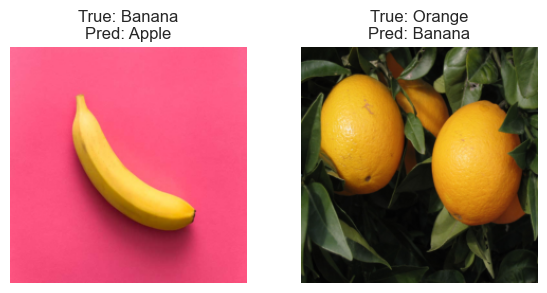

In [20]:
# Investigate misclassified images
y_true = np.array(y_true)
y_pred = np.array(y_pred)
misclass = np.where(y_pred != y_true)[0]
print(f"Indices of misclassified images: {misclass}")

if len(misclass) == 0:
    print("No misclassified images found.")
else:
    # Convert normalization stats for RGB unnormalization during plotting
    mean_np = mean.cpu().numpy().reshape(1, 1, 3)
    std_np = std.cpu().numpy().reshape(1, 1, 3)

    # Create a dynamic grid side-by-side
    fig, axes = plt.subplots(1, len(misclass), figsize=(3 * len(misclass), 3))
    if len(misclass) == 1:
        axes = [axes]

    # Show the misclassified images side by side
    for i, idx in enumerate(misclass):
        img, label = test_dataset[idx]

        # CHW -> HWC
        img_to_show = np.transpose(img.numpy(), (1, 2, 0))

        # Reverse normalization to visualize original colors
        img_to_show = (img_to_show * std_np) + mean_np
        img_to_show = np.clip(img_to_show, 0, 1)

        ax = axes[i]
        pred_label = int(y_pred[idx])
        ax.imshow(img_to_show)
        ax.set_title(f"True: {class_names[int(label)].capitalize()}\nPred: {class_names[pred_label].capitalize()}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## Experiment 3: Data Augmentation Model
After reviewing experiment 2 results, we saw a consistency of 2 misclassified images. To observe the effects of data augmentation on these misclassified images and further improve our model, we have implemented data augmentation.

### Experiment 3A: Geometric Modifications

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Accuracy and Loss Report: Geometric Aug Model


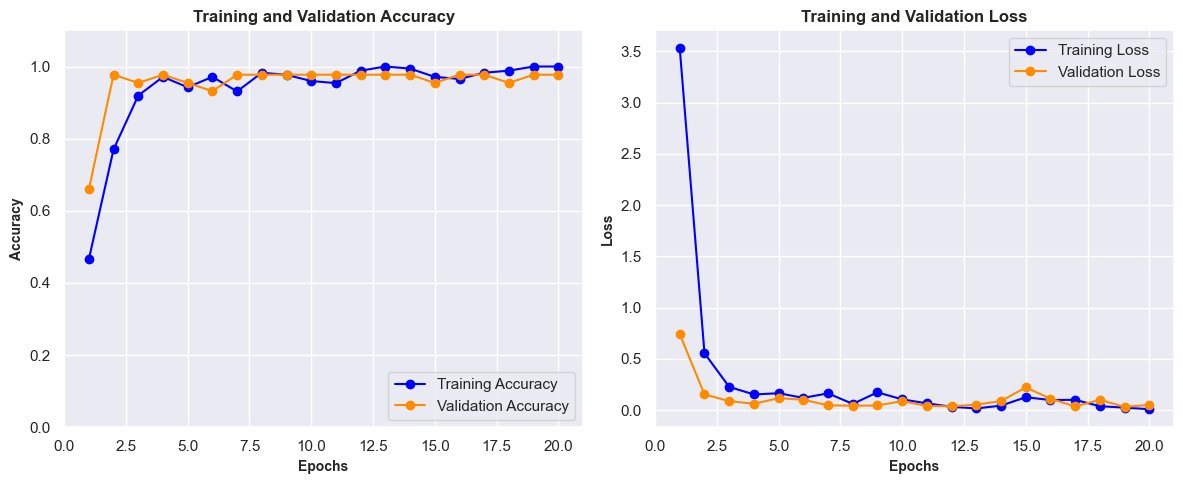


Final Test Accuracy: 0.9636
Final Test Loss: 0.3544

Classification Report: Geometric Aug Model


,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.947000,1.000000,0.973000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.966000,0.963000,0.963000,55.000000
weighted avg,0.966000,0.964000,0.963000,55.000000



Confusion Matrix: Geometric Aug Model


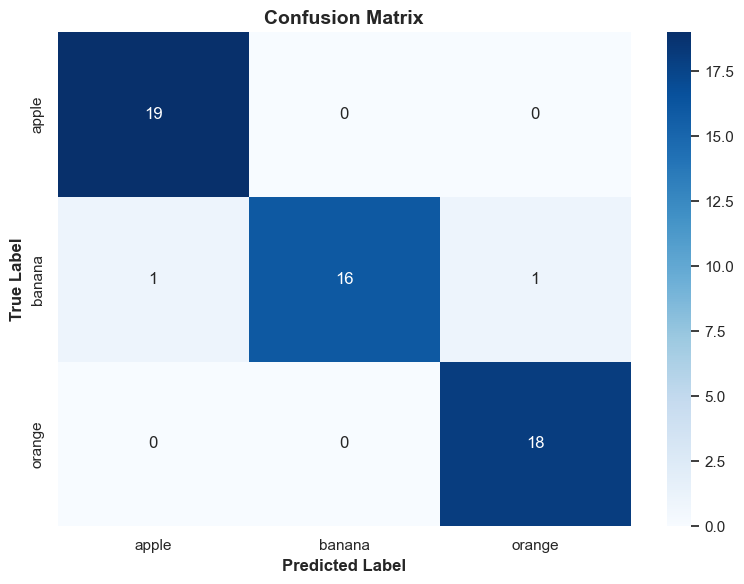

In [21]:
# ========================================================== #
# 10. Model with Geometric Augmentation
# ========================================================== #
# 1. Define BASE geometric augmentation pipeline
exp3a_augmentation = [
    transforms.RandomHorizontalFlip(p=0.5),
    # transforms.RandomRotation(degrees=36),
    # transforms.RandomResizedCrop(size=(224, 224), scale=(0.9, 1.0))
    
    # Less aggressive rotation/resizing
    transforms.RandomAffine(
        degrees=15,
        translate=(0.08, 0.08),
        scale=(0.92, 1.08),
        shear=5
    )
]

# 2. Transform with augmentation
exp3a_train_transforms = transform(mean, std, exp3a_augmentation)
exp3a_train_dataset = FruitLabeller(train_df, img_train_dir, exp3a_train_transforms, label_map)
exp3a_train_loader = make_dataloader(exp3a_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 3. Build, compile, and train model
model_experiment_3a = build_model(0.5)
compile_model(model_experiment_3a)
exp3a_history, exp3a_training_time = train_model(model_experiment_3a, epoch=20, loader=exp3a_train_loader)

# 4. Get predictions for the new model
y_true, y_pred, exp3a_inference_time = get_predictions(model_experiment_3a)
exp3a_test_loss, exp3a_test_accuracy = model_experiment_3a.evaluate(test_loader, verbose=0)

# 5. Build the result registry profile
exp3a_result = build_result(
    "Geometric Aug Model",
    exp3a_history,
    y_true,
    y_pred,
    exp3a_training_time,
    exp3a_inference_time,
    exp3a_test_accuracy,
    exp3a_test_loss
)

# 6. Generate accuracy/loss, classification, confusion matrix reports
render_accuracy_loss_report(exp3a_result)
render_classification_report(exp3a_result)
render_confusion_matrix(exp3a_result)

### Experiment 3B: Geometric + Blur Modifications

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Accuracy and Loss Report: Geometric + Blur Aug Model


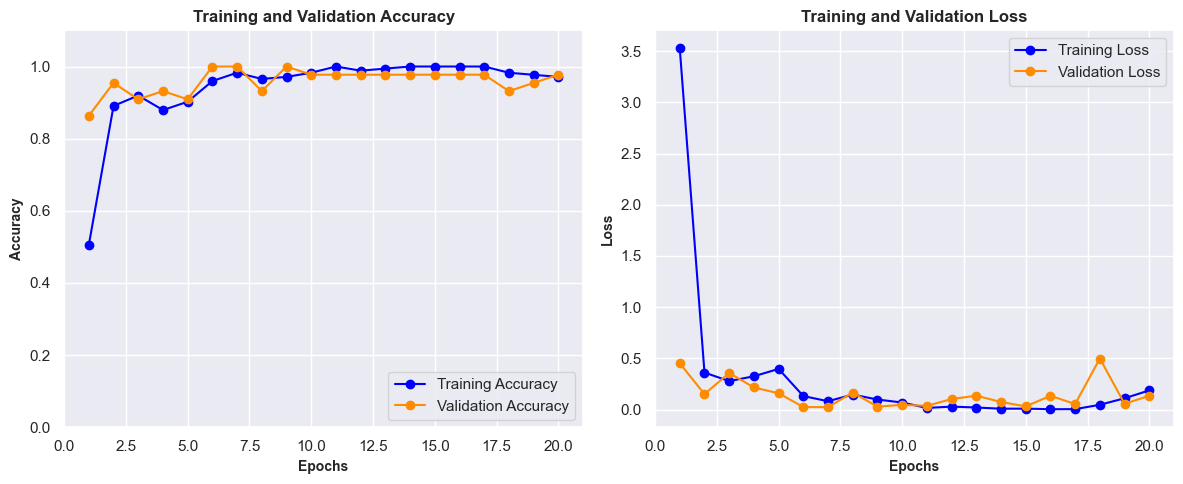


Final Test Accuracy: 0.9455
Final Test Loss: 0.0831

Classification Report: Geometric + Blur Aug Model


,precision,recall,f1-score,support
apple,0.947000,0.947000,0.947000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.900000,1.000000,0.947000,18.000000
accuracy,0.945000,0.945000,0.945000,0.945000
macro avg,0.949000,0.945000,0.945000,55.000000
weighted avg,0.949000,0.945000,0.945000,55.000000



Confusion Matrix: Geometric + Blur Aug Model


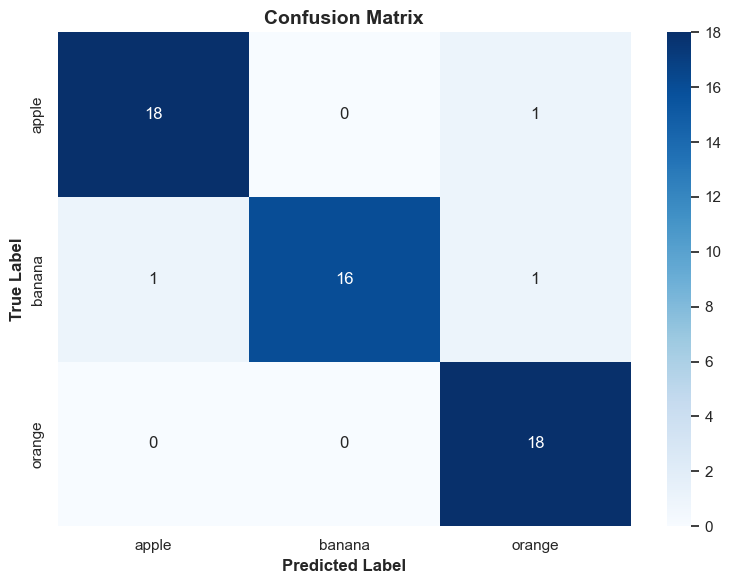

In [22]:
# ========================================================== #
# 11. Model with Geometric + Blur Augmentation
# ========================================================== #
# 1. Exp3b: Geometric augmentation + Gaussian Blur (extend base)
exp3b_augmentation = exp3a_augmentation + [ transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.3)) ]

# 2. Transform with augmentation
exp3b_train_transforms = transform(mean, std, exp3b_augmentation)
exp3b_train_dataset = FruitLabeller(train_df, img_train_dir, exp3b_train_transforms, label_map)
exp3b_train_loader = make_dataloader(exp3b_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 3. Build, compile, and train model
model_experiment_3b = build_model(0.5)
compile_model(model_experiment_3b)
exp3b_history, exp3b_training_time = train_model(model_experiment_3b, epoch=20, loader=exp3b_train_loader)

# 4. Get predictions for the new model
y_true, y_pred, exp3b_inference_time = get_predictions(model_experiment_3b)
exp3b_test_loss, exp3b_test_accuracy = model_experiment_3b.evaluate(test_loader, verbose=0)

# 5. Build the result registry profile
exp3b_result = build_result(
    "Geometric + Blur Aug Model",
    exp3b_history,
    y_true,
    y_pred,
    exp3b_training_time,
    exp3b_inference_time,
    exp3b_test_accuracy,
    exp3b_test_loss
)

# 6. Generate accuracy/loss, classification, confusion matrix reports
render_accuracy_loss_report(exp3b_result)
render_classification_report(exp3b_result)
render_confusion_matrix(exp3b_result)

### Experiment 3C: Photometric Modifications

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Accuracy and Loss Report: Photometric Aug Model


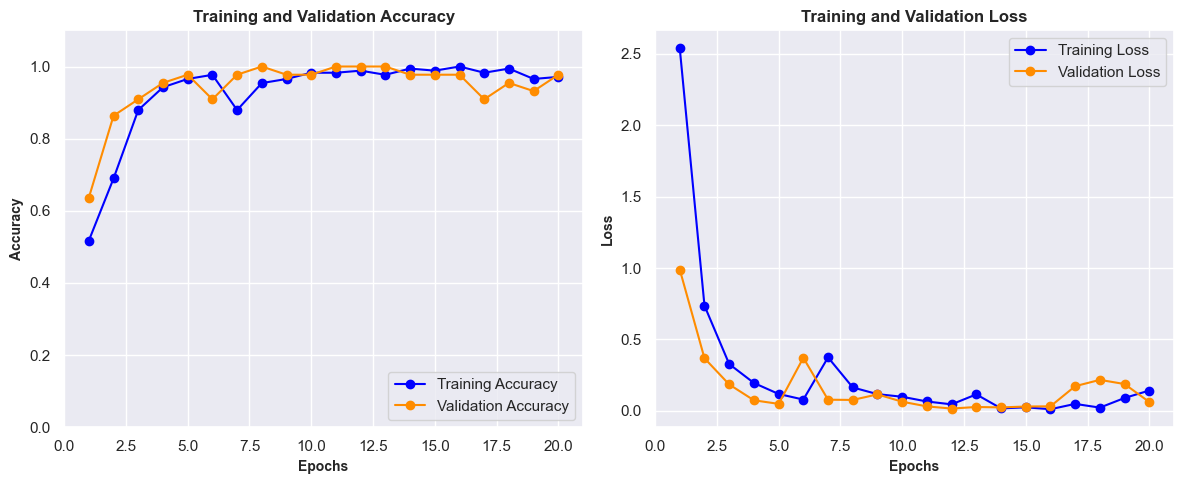


Final Test Accuracy: 0.9636
Final Test Loss: 0.3049

Classification Report: Photometric Aug Model


,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.947000,1.000000,0.973000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.966000,0.963000,0.963000,55.000000
weighted avg,0.966000,0.964000,0.963000,55.000000



Confusion Matrix: Photometric Aug Model


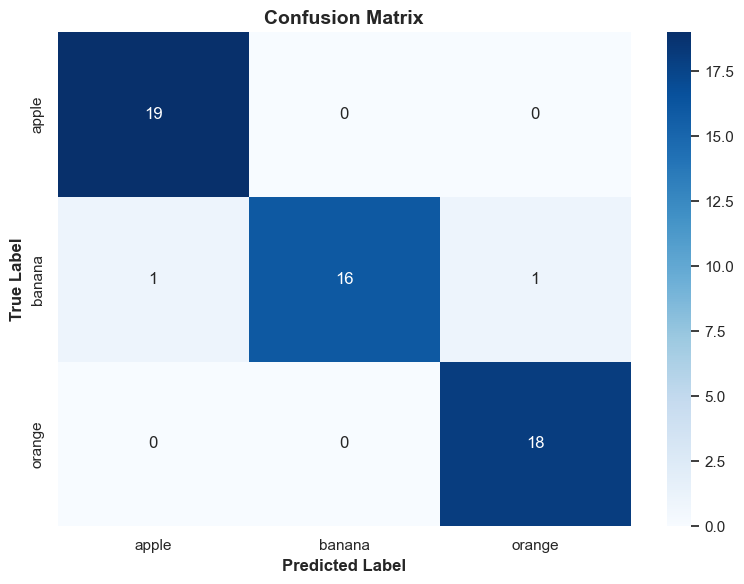

In [23]:
# ========================================================== #
# 12. Model with Photometric Augmentation
# ========================================================== #
# 1. Define the data augmentation pipeline for Experiment 3C
# Skipping saturation and hue as colour is important for fruit classifier
exp3c_augmentation = [
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.0,
        hue=0.0
    )     
]

# 2. Transform with augmentation
exp3c_train_transforms = transform(mean, std, exp3c_augmentation)
exp3c_train_dataset = FruitLabeller(train_df, img_train_dir, exp3c_train_transforms, label_map)
exp3c_train_loader = make_dataloader(exp3c_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 3. Build, compile, and train model
model_experiment_3c = build_model(0.5)
compile_model(model_experiment_3c)
exp3c_history, exp3c_training_time = train_model(model_experiment_3c, epoch=20, loader=exp3c_train_loader)

# 4. Get predictions for the new model
y_true, y_pred, exp3c_inference_time = get_predictions(model_experiment_3c)
exp3c_test_loss, exp3c_test_accuracy = model_experiment_3c.evaluate(test_loader, verbose=0)

# 5. Build the result registry profile
exp3c_result = build_result(
    "Photometric Aug Model",
    exp3c_history,
    y_true,
    y_pred,
    exp3c_training_time,
    exp3c_inference_time,
    exp3c_test_accuracy,
    exp3c_test_loss
)

# 6. Generate accuracy/loss, classification, confusion matrix reports
render_accuracy_loss_report(exp3c_result)
render_classification_report(exp3c_result)
render_confusion_matrix(exp3c_result)

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Accuracy and Loss Report: Geometric + Photometric Aug Model


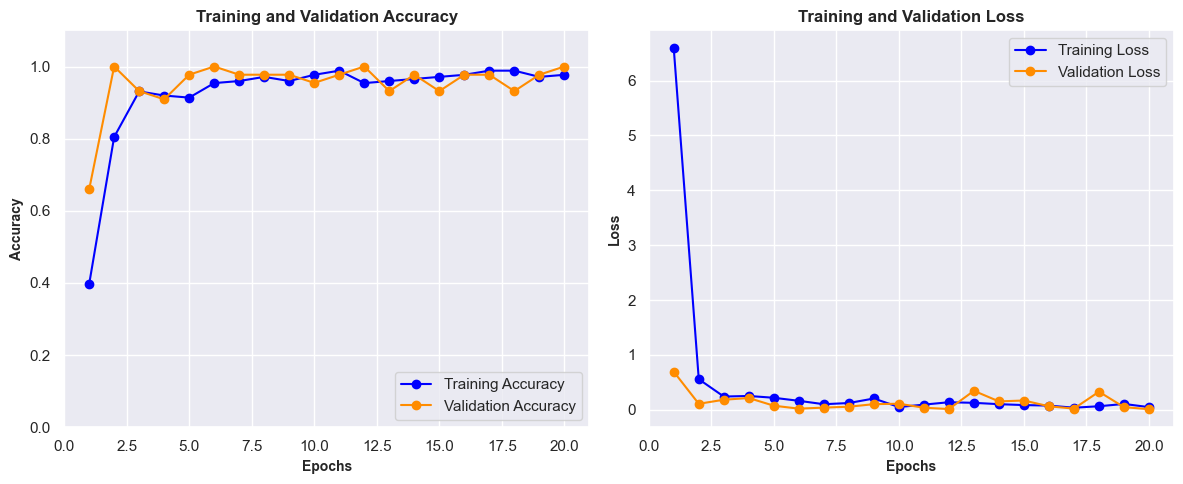


Final Test Accuracy: 0.9455
Final Test Loss: 0.1633

Classification Report: Geometric + Photometric Aug Model


,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,0.941000,0.889000,0.914000,18.000000
orange,0.944000,0.944000,0.944000,18.000000
accuracy,0.945000,0.945000,0.945000,0.945000
macro avg,0.945000,0.944000,0.944000,55.000000
weighted avg,0.945000,0.945000,0.945000,55.000000



Confusion Matrix: Geometric + Photometric Aug Model


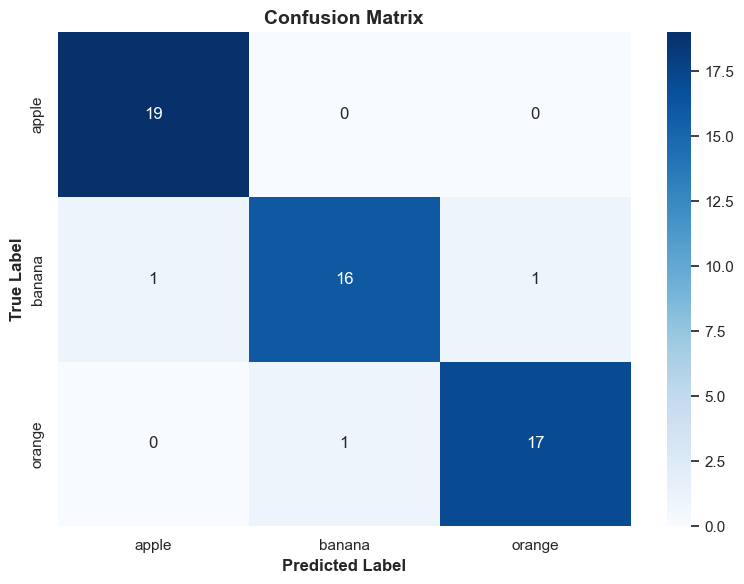

In [24]:
# ========================================================== #
# 13. Model with Geometric + Photometric Augmentation
# ========================================================== #
# 1. Combined aug transforms
exp3d_augmentation = exp3a_augmentation + exp3c_augmentation
exp3d_train_transforms = transform(mean, std, exp3d_augmentation)
exp3d_train_dataset = FruitLabeller(train_df, img_train_dir, exp3d_train_transforms, label_map)
exp3d_train_loader = make_dataloader(exp3d_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 2. Build, compile, and train model
model_experiment_3d = build_model(0.5)
compile_model(model_experiment_3d)
exp3d_history, exp3d_training_time = train_model(model_experiment_3d, epoch=20, loader=exp3d_train_loader)

# 3. Get predictions
y_true, y_pred, exp3d_inference_time = get_predictions(model_experiment_3d)
exp3d_test_loss, exp3d_test_accuracy = model_experiment_3d.evaluate(test_loader, verbose=0)

# 4. Build result
exp3d_result = build_result(
    "Geometric + Photometric Aug Model",
    exp3d_history, 
    y_true, 
    y_pred,
    exp3d_training_time, 
    exp3d_inference_time,
    exp3d_test_accuracy, 
    exp3d_test_loss
)

# 5. Generate accuracy/loss, classification, confusion matrix reports
render_accuracy_loss_report(exp3d_result)
render_classification_report(exp3d_result)
render_confusion_matrix(exp3d_result)

## Experiment 4: Transfer Learning Model

In [25]:
# ========================================================== #
# 24. Compile and Train Model using Transfer Learning
# ========================================================== #

# 1. Instantiate Pre-trained MobileNetV2 model without its classification head.
keras.config.set_image_data_format('channels_first')
model_pretrained = keras.applications.MobileNetV2(
    input_shape=(3, 224, 224),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the pre-trained model so its pre-learned feature maps are not destroyed
model_pretrained.trainable = False

# 3. Build the custom classification model incorporating the 
model_experiment_4 = Sequential([
    Input(shape=(3, 224, 224)),
    
    # Preprocessing: MobileNetV2 expects pixel values between [-1, 1].
    Rescaling(scale=2.0, offset=-1.0),
    
    # Pass the scaled images through the frozen MobileNetV2 base
    model_pretrained,
    
    # Compress the spatial dimensions while retaining feature depth.
    GlobalAveragePooling2D(data_format="channels_first"),
    
    # Add your custom dense layers for the 3 fruit classes
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

# 4. Compile and train the model
compile_model(model_experiment_4)
model_experiment_4.summary()
exp4_history, exp4_training_time = train_model(model_experiment_4)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280, 7, 7)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Accuracy and Loss Report: MobileNetV2 TL Model


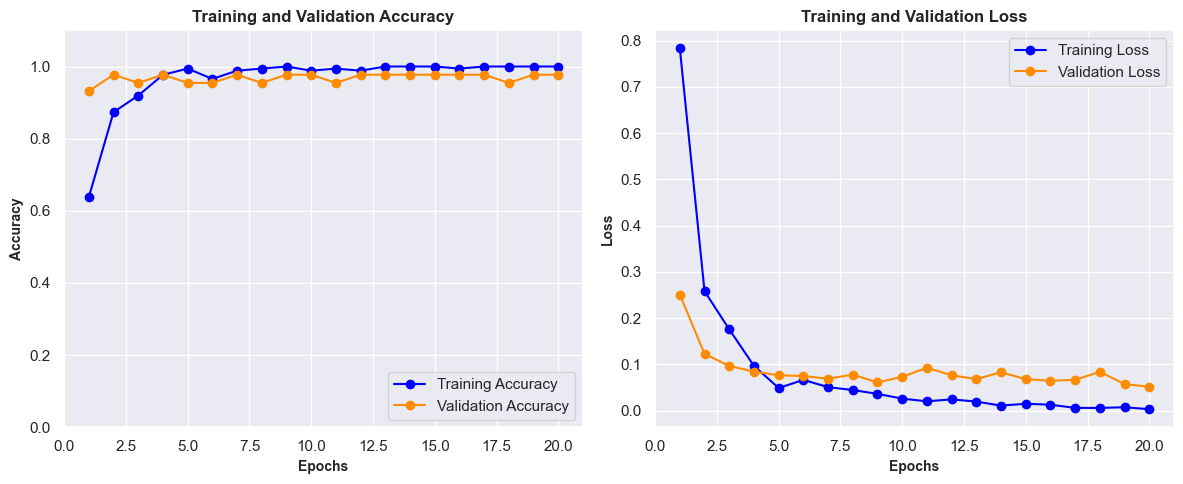


Final Test Accuracy: 0.9455
Final Test Loss: 0.1460

Classification Report: MobileNetV2 TL Model


,precision,recall,f1-score,support
apple,0.900000,0.947000,0.923000,19.000000
banana,1.000000,1.000000,1.000000,18.000000
orange,0.941000,0.889000,0.914000,18.000000
accuracy,0.945000,0.945000,0.945000,0.945000
macro avg,0.947000,0.945000,0.946000,55.000000
weighted avg,0.946000,0.945000,0.945000,55.000000



Confusion Matrix: MobileNetV2 TL Model


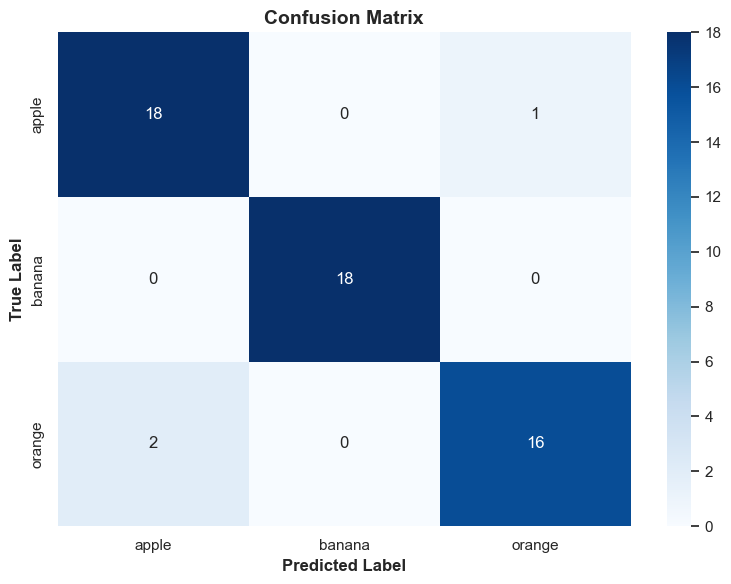

In [26]:
# ========================================================
# 25. Evaluate Model with Transfer Learning + Dropout 0.5
# ========================================================

# 1. Get predictions for the new model
y_true, y_pred, exp4_inference_time = get_predictions(model_experiment_4)
exp4_test_loss, exp4_test_accuracy = model_experiment_4.evaluate(test_loader, verbose=0)

# 2. Build the result registry profile
exp4_result = build_result(
    "MobileNetV2 TL Model",
    exp4_history,
    y_true,
    y_pred,
    exp4_training_time,
    exp4_inference_time,
    exp4_test_accuracy,
    exp4_test_loss
)

# 3. Generate and render Accuracy and Loss Report
render_accuracy_loss_report(exp4_result)
render_classification_report(exp4_result)
render_confusion_matrix(exp4_result)

## Summary of Findings
1. Misclassified Images
2. Test Accuracy across Experiments
3. Model Efficiency across Experiments

Summary of Findings

1 Overall Findings from the CA

A. Finding

The experiments demonstrated that fruit classification performance was influenced by multiple factors, including learning rate selection, regularisation strategy, data augmentation, and model architecture. While all CNN-based models achieved relatively strong results, the impact of each optimisation technique varied considerably across the experiments.

B. Evidence

The baseline CNN achieved a test accuracy of 94.55%, confirming that the proposed architecture was capable of learning meaningful visual features from the fruit dataset. Performance improved to 96.36% following learning rate optimisation and reached 98.18% with the Dropout 0.5 configuration. Geometric augmentation maintained strong classification performance, whereas photometric augmentation reduced accuracy to 85.45%. In addition, the MobileNetV2 transfer learning model achieved 96.36%, demonstrating competitive performance but not surpassing the strongest custom CNN configuration.

C. Analysis

Several important observations emerged from the experimental results. First, improvements in performance were not directly associated with increased model complexity. Although transfer learning provided stable and reliable results, a carefully optimised CNN achieved superior performance on this dataset. Second, optimisation strategies such as learning rate tuning and dropout regularisation contributed more to performance improvement than architectural changes. Finally, the augmentation experiments highlighted that the effectiveness of data augmentation depends on the type of transformation applied. Transformations that preserved the essential visual characteristics of the fruit images were beneficial, whereas more aggressive modifications could negatively affect classification performance.


2 Misclassified Images

A. Finding

Classification errors were extremely limited and concentrated within a very small number of challenging samples.

B. Evidence

The best-performing Dropout 0.5 model achieved a test accuracy of 98.18%, correctly classifying 54 out of 55 test images. Only one image was misclassified. The transfer learning model achieved 96.36% accuracy and misclassified two images, both involving confusion between Apple and Orange categories.

C. Analysis

The low number of errors indicates that the model successfully learned highly discriminative visual features for all three fruit categories. Another notable observation was that the remaining errors were not randomly distributed. Instead, they occurred between visually similar classes, suggesting that some overlap existed within the learned feature representations of Apple and Orange images.

Banana images were consistently classified with high accuracy across experiments, indicating that their visual characteristics were easier for the model to distinguish.

D. Implication

Future improvements should focus on analysing difficult class boundaries and ambiguous samples rather than redesigning the overall architecture.

E. Conclusion

The misclassification analysis confirms that the final model achieved strong class separation and reliable predictive performance, with only a small number of class-specific errors remaining.



3 Test Accuracy Across Experiments

A. Finding

Model performance improved progressively through appropriate hyperparameter tuning and regularisation, although not every modification resulted in positive outcomes.

B. Evidence

Compared with the baseline accuracy of 94.55%, reducing the learning rate to 0.0005 improved performance to 96.36%. However, further reductions to 0.00001 and 0.000005 lowered accuracy to 90.91% and 92.73%, respectively.

Among the dropout experiments, the 0.5 configuration achieved the highest accuracy of 98.18%, while both the 0.3 and 0.7 configurations achieved 96.36%.

Data augmentation produced mixed results. Geometric augmentation maintained strong performance at 96.36%, whereas photometric augmentation reduced accuracy significantly to 85.45%. Transfer learning achieved 96.36%.

C. Analysis

Several important observations emerged from these experiments. First, moderate adjustments to the learning rate improved optimisation performance, but excessively small learning rates prevented the model from learning efficiently within the available training epochs.

Second, dropout regularisation proved highly effective. The superior performance of the 0.5 configuration suggests that moderate regularisation reduced overfitting while preserving useful feature information. In contrast, both weaker and stronger dropout settings were less effective.

Finally, the augmentation experiments demonstrated that not all transformations are equally beneficial. Geometric transformations preserved essential visual characteristics of the fruit images, whereas aggressive colour and brightness modifications appeared to distort features that were important for classification.

D. Implication

The results emphasise that model performance depends on finding an appropriate balance between training parameters, regularisation strength, and data preprocessing strategies.

E. Conclusion

Among all experiments, the Dropout 0.5 configuration produced the strongest classification performance and emerged as the best-performing model in the project.



 4. Model Efficiency Across Experiments

A. Finding

The most accurate model was also one of the most efficient models evaluated throughout the project.

B. Evidence

The Dropout 0.5 model achieved the highest test accuracy while maintaining reasonable training and inference times. In contrast, experiments using extremely small learning rates required substantially longer training times despite producing lower accuracy. Transfer learning reduced training effort but resulted in slower inference performance than the custom CNN models.

C. Analysis

The efficiency results reveal that higher computational complexity does not necessarily lead to better classification performance. Although transfer learning introduced a more advanced architecture, it did not outperform the best custom CNN. Similarly, reducing the learning rate significantly increased training time without producing corresponding improvements in accuracy.

These observations suggest that efficiency should be evaluated alongside predictive performance when selecting a final model.

D. Implication

For practical deployment scenarios, model selection should consider not only classification accuracy but also computational requirements and inference speed.

E. Conclusion

The Dropout 0.5 model achieved the most favourable balance between predictive performance, training efficiency, and deployment practicality.



5. Overall Conclusion

The project successfully achieved its objective of developing an effective fruit image classification model. Through systematic experimentation, the effects of learning rate tuning, regularisation, data augmentation, and transfer learning were evaluated and compared.

Among all evaluated approaches, the Dropout 0.5 CNN model delivered the strongest overall performance, achieving the highest test accuracy of 98.18% while maintaining efficient computational performance and strong generalisation capability.

Overall, the findings demonstrate that careful model optimisation contributed more to performance improvement than increased architectural complexity. Based on the experimental results, the Dropout 0.5 CNN model is recommended as the final model for this project.


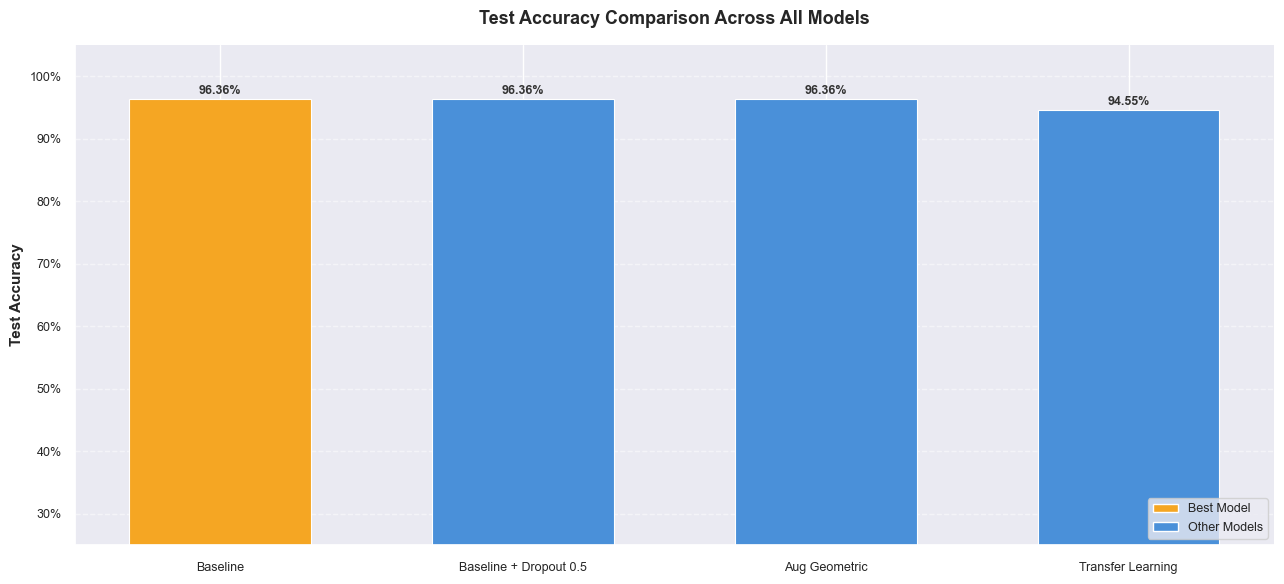

Best Model: Baseline
Best Accuracy: 96.36%


In [27]:
# ========================================================== #
# 26. Test Accuracy Comparison Bar Chart Across All Models
#     Purpose: Visualise and compare the final test accuracy of
#     every model trained in this notebook using a bar chart.
# ========================================================== #

# Collect best results at each experiment stage
all_results = [
    baseline_result,
    dropout_05_result,
    exp3a_result,
    exp4_result
]

# Short display names for the x-axis
short_names = [
    "Baseline",
    "Baseline + Dropout 0.5",
    "Aug Geometric",
    "Transfer Learning"
]

# Extract test accuracies
test_accuracies = [r['test_accuracy'] for r in all_results]

# Identify the best model
best_idx = test_accuracies.index(max(test_accuracies))

# Assign bar colours
bar_colours = ['#f5a623' if i == best_idx else '#4a90d9' for i in range(len(short_names))]

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(short_names, test_accuracies, color=bar_colours, edgecolor='white', linewidth=0.8, width=0.6)

# Annotate each bar with its accuracy value
for bar, acc in zip(bars, test_accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{acc:.2%}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#333333'
    )

# Formatting
ax.set_ylim(0.25, 1.05)
ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Test Accuracy Comparison Across All Models', fontsize=13, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.tick_params(axis='x', labelsize=9, pad=6)
ax.tick_params(axis='y', labelsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#f5a623', label='Best Model'),
    Patch(facecolor='#4a90d9', label='Other Models'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Best Model: {short_names[best_idx]}")
print(f"Best Accuracy: {test_accuracies[best_idx]:.2%}")

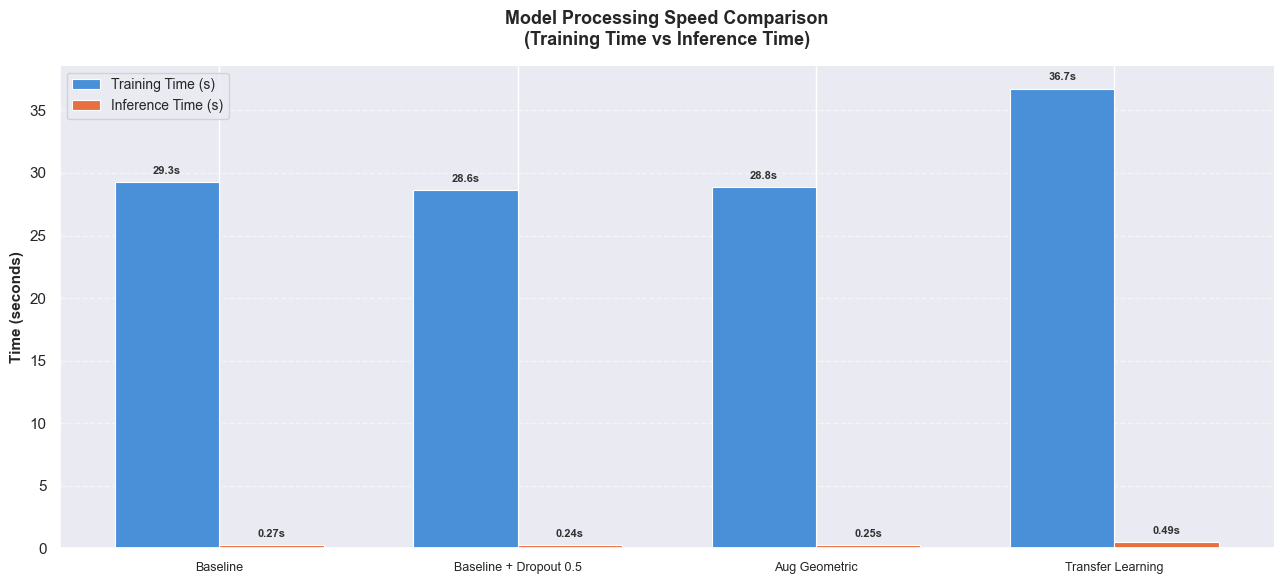

Model                           Training Time (s)   Inference Time (s)
Baseline Model                              29.27               0.2745
Dropout 0.5 Model                           28.65               0.2378
Geometric Aug Model                         28.85               0.2539
MobileNetV2 TL Model                        36.73               0.4865
Fastest training: Dropout 0.5 Model (28.65s)
Fastest inference: Dropout 0.5 Model (0.2378s)


In [28]:
# ========================================================== #
# 27. Summary Sheet: Model Efficiency Comparison
#     Processing Speed — Training Time vs Inference Time
#     across all models from Section 26
# ========================================================== #

import matplotlib.pyplot as plt
import numpy as np

training_times = [result['training_time'] for result in all_results]
inference_times = [result['inference_time'] for result in all_results]

# 1) Grouped Bar Chart — Training vs Inference Time
x = np.arange(len(short_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars_train = ax.bar(x - width/2, training_times, width, label="Training Time (s)", color="#4a90d9", edgecolor="white", linewidth=0.8)
bars_infer = ax.bar(x + width/2, inference_times, width, label="Inference Time (s)", color="#e87040", edgecolor="white", linewidth=0.8)

# Annotate bars
for bar in bars_train:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}s",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="#333333"
    )

for bar in bars_infer:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.2f}s",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="#333333"
    )

ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=9)
ax.set_ylabel("Time (seconds)", fontsize=11, fontweight="bold")
ax.set_title("Model Processing Speed Comparison\n(Training Time vs Inference Time)", fontsize=13, fontweight="bold", pad=15)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 2) Text Summary
fastest_train_idx = training_times.index(min(training_times))
fastest_infer_idx = inference_times.index(min(inference_times))
flat_labels = [result['name'] for result in all_results]

print("=" * 72)
print(f"{'Model':<30} {'Training Time (s)':>18} {'Inference Time (s)':>20}")
print("=" * 72)

for label, tr, inf in zip(flat_labels, training_times, inference_times):
    print(f"{label:<30} {tr:>18.2f} {inf:>20.4f}")

print("=" * 72)
print(f"Fastest training: {flat_labels[fastest_train_idx]} ({training_times[fastest_train_idx]:.2f}s)")
print(f"Fastest inference: {flat_labels[fastest_infer_idx]} ({inference_times[fastest_infer_idx]:.4f}s)")